In [2]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeJakarta
from qiskit import QuantumCircuit, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, state_fidelity
from qiskit_experiments.framework import ParallelExperiment
from qiskit_experiments.library import StateTomography
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.linalg import sqrtm
# ideal_backend = AerSimulator()

In [1]:
text = "Currently, we are in a stage where quantum computers surpass the size that can be simulated exactly on classical computers, and noise is the central issue in extracting their full potential. Effective ways to characterize and measure their progress for practical applications are needed. In this work, we use the linear ramp quantum approximate optimization algorithm (LR-QAOA) protocol, a fixed quantum approximate optimization algorithm (QAOA) protocol, as an easy-to-implement scalable benchmarking methodology that assesses quantum process units (QPUs) at different widths (number of qubits) and 2-qubit gate depths. The benchmarking identifies the depth at which a fully mixed state is reached, and therefore, the results cannot be distinguished from those of a random sampler. We test this methodology using three graph topologies: 1D-chain, native layout, and fully connected graphs, on 19 different QPUs from 5 vendors: IBM, IQM, IonQ, Quantinuum, and Rigetti for problem sizes requiring from Nq=5 to Nq=156 qubits and LR-QAOA number of layers from p=3 to p=10,000. In the case of 1D-chain and native graphs, ibm_fez, the system with the largest number of qubits, performs best at p=15 for problems involving Nq=100 and Nq=156 qubits and 1,485 and 2,640 2-qubit gates, respectively. For the native graph problem, ibm_fez still retains some coherent information at p=200 involving 35,200 fractional 2-qubit gates. Our largest implementation is a 1D-chain problem with p=10,000 involving 990,000 2-qubit gates on ibm_fez. For fully connected graph problems, quantinuum_H2-1 shows the best performance, passing the test with Nq=56 qubits at p=3 involving 4,620 2-qubit gates with the largest 2-qubit gate implementation for a problem with Nq=50 qubits and p=10 involving 12,250 2-qubit gates but not passing the test."
len(text.split(" "))

273

In [ ]:
import qiskit_aer.noise as noise
from qiskit_aer import AerSimulator, QasmSimulator


def create_noisy_backend(prob_1, prob_2):
    # Depolarizing quantum errors
    error_1 = noise.depolarizing_error(prob_1, 1)
    error_2 = noise.depolarizing_error(prob_2, 2)

    # Add errors to noise model
    noise_model = noise.NoiseModel()
    noise_model.add_all_qubit_quantum_error(error_1, ['rz', 'sx', 'x'])
    noise_model.add_all_qubit_quantum_error(error_2, ['cx', "rzz"])
    # sim_noise = AerSimulator(noise_model=noise_model)
    sim_noise = QasmSimulator(method="density_matrix",
                              noise_model=noise_model)
    return sim_noise


In [4]:
zero_state = np.array([[1,0],[0,0]], dtype=complex)
one_state = np.array([[0,0],[0,1]], dtype=complex)
phase_z = np.array([[1,0],[0,-1j]], dtype=complex)
hadamard = (1/np.sqrt(2)) * np.array([[1,1],[1,-1]], dtype=complex)
identity = np.eye(2, dtype=complex)
unitaries = [hadamard, hadamard @ phase_z , identity]

def classical_shadows_circuits(circuit, unitary_ids, backend):
    """
    Input:
        circuit: Qiskit circuit that one wants to know the density matrix
        unitary_ids: Random basis to measure the circuit to recover the Classical Shadows information
        backend: Where the circuit will run (Important to transpile in terms of the backend layout) 
    Return: Circuit with the classical shadows basis.
    """
    num_shadow = len(unitary_ids)
    num_qubits = circuit.num_qubits
    qcs = []
    for shadow_i in range(num_shadow):
        qc_g = QuantumCircuit(num_qubits)
        for i in range(num_qubits):
            if unitary_ids[shadow_i, i] == 0:
                qc_g.h(i)
            elif unitary_ids[shadow_i, i] == 1:
                qc_g.sdg(i)
                qc_g.h(i) 
            elif unitary_ids[shadow_i, i] == 2:
                pass
            else:
                raise ValueError("This is not a valid pauli string")
        qc_g = transpile(qc_g, backend, optimization_level=0)
        qc = circuit.compose(qc_g, range(num_qubits))
        qc.add_register(ClassicalRegister(num_qubits))
        qc.measure(range(num_qubits), reversed(range(num_qubits)))
        qcs.append(qc)
        if not shadow_i % (num_shadow//10):
            print(f" Shadows: {shadow_i}")
    return qcs

def snapshot_state(b_list, obs_list, list_qubits):
    num_qubits = len(b_list)
    if len(list_qubits) == 0:
        list_qubits = range(num_qubits)
    # computational basis state
    rho_snapshot = [1]
    for i in reversed(list_qubits):
        state = zero_state if b_list[i] == "0" else one_state
        U = unitaries[obs_list[i]] 
        local_rho = 3 * (U.conj().T @ state @ U) - identity # Eq. S44 classical shadows paper
        rho_snapshot = np.kron(rho_snapshot, local_rho)
    return rho_snapshot

def shadow_state_reconstruction(shadow, basis, list_qubits):
    num_snapshots = len(shadow)
    num_qubits = len(list_qubits)
    
    shadow_rho = np.zeros((2 ** num_qubits, 2 ** num_qubits), dtype=complex)
    for i in range(num_snapshots):
        shadow_rho += snapshot_state(shadow[i], basis[i], list_qubits)
    
    return shadow_rho / num_snapshots

def zecs(p):
    """
    Find the singular vector corresponding to the smallest singular value 
    (which can approximate the zero energy coherent state, ZEC).

    Parameters:
    p (numpy.ndarray): A density matrix or any square matrix.

    Returns:
    numpy.ndarray: The singular vector corresponding to the smallest singular value.
    """
    
    # Step 1: Perform Singular Value Decomposition (SVD) of the input matrix p.
    # np.linalg.svd returns three matrices: U and singular values (S).
    U, S, _ = np.linalg.svd(p, hermitian=True)
    
    # Step 2: Extract the right-singular vector (fist column of U) corresponding to the largest singular value.
    # This state vector contains the largest overlap with the ideal state vector that described the given circuit.
    best_sv = U[:,0].reshape(-1, 1)  # Reshaping into a column vector.

    # Step 3: Return the singular vector corresponding to the largest singular value.
    return best_sv

def qst_zecs(qc, list_shadows, backend):
    num_qubits = qc.num_qubits
    unitaries = np.random.randint(0, 3, size=(list_shadows[-1], num_qubits))
    qcs = classical_shadows_circuits(qc, unitaries,  backend)
    outcomes = [list(i.keys())[0] for i in backend.run(qcs, shots=1).result().get_counts()]
    p_zecs = {}
    for shots in list_shadows:
        rho_cs = shadow_state_reconstruction(outcomes[:shots], unitaries[:shots], list_qubits=range(num_qubits))
        sv_zecs = zecs(rho_cs) # Zero-Entropy classical shadows state
        rho_zecs = sv_zecs @ sv_zecs.T.conj() #density matrix ZECS
        p_zecs[shots] = {"p_zecs":rho_zecs}
    return p_zecs


In [5]:
def qaoa_circ(G, gammas, betas):
    n_qubits = G.number_of_nodes()
    p = len(gammas)
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    for ii in range(p):
        for i, j in G.edges():
            qc.rzz(2*gammas[ii]*G[i][j]["weight"], i, j)
        qc.rx(-2*betas[ii], range(n_qubits))
    return qc

In [4]:
results = np.load("/Users/alejomonbar/Documents/GitHub/LR-QAOA/Data/WMaxCut/problems.npy", allow_pickle=True).item()

# GHZ

In [71]:
results = defaultdict(dict)
error_1q = 0
# error_2q = 5e-3
error_2q = 100e-3
backend = create_noisy_backend(error_1q, error_2q)
shots_list = [1,2,3,5,10,20] 
nq = 5
qc = QuantumCircuit(nq)
qc.h(0)
for i in range(nq-1):
    qc.cx(i,i+1)
p_ideal = np.array(DensityMatrix(qc))
results["p_ideal"] = p_ideal 
qstexp1 = StateTomography(qc)
results["num_qc_qst"] = len(qstexp1.circuits())
F_qst = []
for shots in shots_list:
    qstdata1 = qstexp1.run(backend, shots=shots).block_for_results()
    p_qst = np.array(qstdata1.analysis_results()[0].value)
    F_qst.append(state_fidelity(p_ideal, p_qst))
    results[shots*results["num_qc_qst"]]["p_qst"] = p_qst

results["shots_list"] = [shots * results["num_qc_qst"] for shots in shots_list]
p_zecs = qst_zecs(qc, results["shots_list"], backend)
for shots in results["shots_list"]:
    results[shots]["p_zecs"] = p_zecs[shots]["p_zecs"] 
results["F_zecs"] = [state_fidelity(p_ideal, results[shots]["p_zecs"]) for shots in results["shots_list"]]

    
results["F_qst"] = F_qst
np.save(f"./Data/qst_GHZ_nq{nq}_{error_2q}.npy", results)

/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python

 Shadows: 0
 Shadows: 486
 Shadows: 972
 Shadows: 1458
 Shadows: 1944
 Shadows: 2430
 Shadows: 2916
 Shadows: 3402
 Shadows: 3888
 Shadows: 4374


# LR-QAOA

In [64]:
problem = np.load("./Data/problem_5q.npy", allow_pickle=True).item()
results = defaultdict(dict)
error_1q = 0
# error_2q = 5e-3
error_2q = 1e-2
backend = create_noisy_backend(error_1q, error_2q)
G = problem["G"]
p = 3
delta_gamma = 1
delta_beta = 1
gammas = np.arange(1,p+1) * delta_gamma/p
betas = np.arange(1,p+1)[::-1] * delta_beta/p
F_qst = []
F_zecs = []
shots_list = [1,2,3,5,10] 

qc = qaoa_circ(G, gammas, betas)
p_ideal = np.array(DensityMatrix(qc))
results["p_ideal"] = p_ideal 
qstexp1 = StateTomography(qc)
results["num_qc_qst"] = len(qstexp1.circuits())
for shots in shots_list:
    qstdata1 = qstexp1.run(backend, shots=shots).block_for_results()
    p_qst = np.array(qstdata1.analysis_results()[0].value)
    F_qst.append(state_fidelity(p_ideal, p_qst))
    results[shots*results["num_qc_qst"]]["p_qst"] = p_qst

results["shots_list"] = [shots * results["num_qc_qst"] for shots in shots_list]
p_zecs = qst_zecs(qc, results["shots_list"], backend)
for shots in results["shots_list"]:
    results[shots]["p_zecs"] = p_zecs[shots]["p_zecs"] 
results["F_zecs"] = [state_fidelity(p_ideal, results[shots]["p_zecs"]) for shots in results["shots_list"]]

    
results["F_qst"] = F_qst
results["G"] = G
results["p"] = p 
results["gammas"] = gammas
results["betas"] = betas
np.save(f"./Data/qst_results_qaoa_5q_p{p}_noise_{error_2q}.npy", results)

/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python3.9/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:232: UserWarning: Options {'execution': {'meas_type': 'classified'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/Users/alejomonbar/Documents/GitHub/ZECS/.conda/lib/python

 Shadows: 0
 Shadows: 243
 Shadows: 486
 Shadows: 729
 Shadows: 972
 Shadows: 1215
 Shadows: 1458
 Shadows: 1701
 Shadows: 1944
 Shadows: 2187


In [65]:
np.save(f"./Data/qst_results_qaoa_5q_p{p}_noise_{error_2q}.npy", results)

Text(0, 0.5, 'Fidelity')

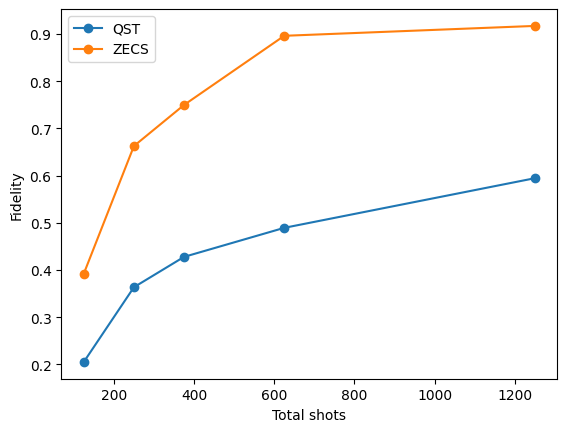

In [68]:
fig, ax = plt.subplots()
num_qubits = G.number_of_nodes()
ax.plot(np.array(shots_list)*num_qubits**3, results["F_qst"], marker="o", label="QST")
ax.plot(np.array(shots_list)*num_qubits**3, results["F_zecs"], marker="o", label="ZECS")
ax.legend()
ax.set_xlabel("Total shots")
ax.set_ylabel("Fidelity")

Text(0, 0.5, 'Fidelity')

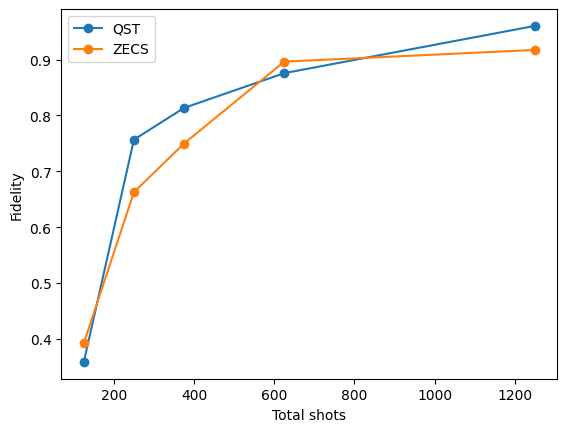

In [69]:
fig, ax = plt.subplots()
num_qubits = G.number_of_nodes()
ax.plot(np.array(shots_list)*num_qubits**3, [state_fidelity(results["p_ideal"],zecs(results[shots]["p_qst"]) )for shots in results["shots_list"]], marker="o", label="QST")
ax.plot(np.array(shots_list)*num_qubits**3, results["F_zecs"], marker="o", label="ZECS")
ax.legend()
ax.set_xlabel("Total shots")
ax.set_ylabel("Fidelity")

In [70]:
# results = np.load("./Data/qst_results_qaoa_5q.npy", allow_pickle=True).item()


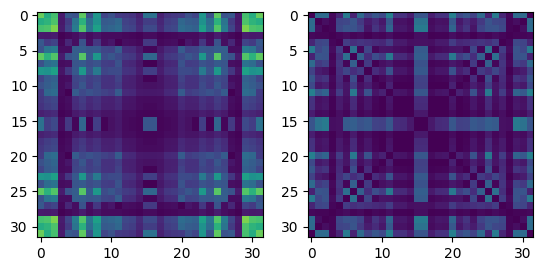

In [72]:
fig, ax = plt.subplots(1,2)
bar = ax[0].imshow(np.abs(p_ideal.real), vmin=0, vmax=0.1)
ax[1].imshow(np.abs(p_ideal.imag), vmin=0, vmax=0.1)


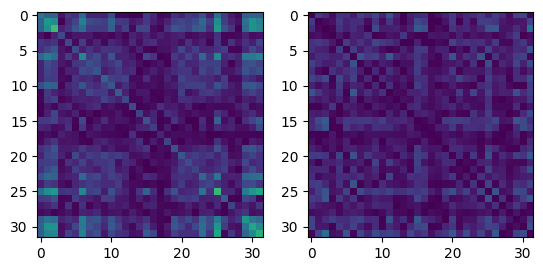

In [73]:
fig, ax = plt.subplots(1,2)
bar = ax[0].imshow(np.abs(p_qst.real), vmin=0, vmax=0.1)
ax[1].imshow(np.abs(p_qst.imag), vmin=0, vmax=0.1)

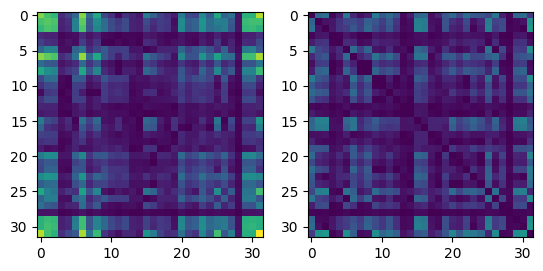

In [75]:
fig, ax = plt.subplots(1,2)
bar = ax[0].imshow(np.abs(p_zecs[shots]["p_zecs"].real), vmin=0, vmax=0.1)
ax[1].imshow(np.abs(p_zecs[shots]["p_zecs"].imag), vmin=0, vmax=0.1)
